In [59]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
import pandas as pd

df = pd.read_csv('heart.csv')

In [60]:
df

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [61]:
from sklearn import preprocessing as p
from sklearn.model_selection import train_test_split

df_scaled = p.StandardScaler().fit_transform(df.iloc[:, :-1])

X_train, X_val, y_train, y_val = train_test_split(df_scaled, df.iloc[:, -1], train_size = 0.6, random_state=1)
X_val, X_test, y_val, y_test = train_test_split(X_val, y_val, train_size = 0.5, random_state=1)



In [62]:
model = tf.keras.Sequential([
        tf.keras.layers.Input(shape = (13)),
        tf.keras.layers.Dense(8, activation = 'relu'),
        tf.keras.layers.Dense(1)
])

In [63]:
model.summary()

Model: "sequential_14"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_39 (Dense)             (None, 8)                 112       
_________________________________________________________________
dense_40 (Dense)             (None, 1)                 9         
Total params: 121
Trainable params: 121
Non-trainable params: 0
_________________________________________________________________


In [64]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [65]:
EPOCHS = 100

history = model.fit(X_train, y_train, epochs = EPOCHS, validation_data=(X_val, y_val))

Epoch 1/100
6/6 [==============================] - 0s 23ms/step - loss: 3.9507 - accuracy: 0.6354 - val_loss: 4.4911 - val_accuracy: 0.6721
Epoch 2/100
6/6 [==============================] - 0s 9ms/step - loss: 3.9023 - accuracy: 0.6464 - val_loss: 4.2595 - val_accuracy: 0.6721
Epoch 3/100
6/6 [==============================] - 0s 10ms/step - loss: 3.8794 - accuracy: 0.6464 - val_loss: 4.2358 - val_accuracy: 0.6885
Epoch 4/100
6/6 [==============================] - 0s 10ms/step - loss: 3.7471 - accuracy: 0.6464 - val_loss: 4.2191 - val_accuracy: 0.6885
Epoch 5/100
6/6 [==============================] - 0s 10ms/step - loss: 3.7143 - accuracy: 0.6575 - val_loss: 4.2055 - val_accuracy: 0.6885
Epoch 6/100
6/6 [==============================] - 0s 9ms/step - loss: 3.6986 - accuracy: 0.6575 - val_loss: 4.1991 - val_accuracy: 0.6885
Epoch 7/100
6/6 [==============================] - 0s 8ms/step - loss: 3.6937 - accuracy: 0.6575 - val_loss: 4.0377 - val_accuracy: 0.6885
Epoch 8/100
6/6 [======

6/6 [==============================] - 0s 6ms/step - loss: 1.9950 - accuracy: 0.7845 - val_loss: 2.8182 - val_accuracy: 0.7049
Epoch 60/100
6/6 [==============================] - 0s 6ms/step - loss: 1.9915 - accuracy: 0.7845 - val_loss: 2.8056 - val_accuracy: 0.7049
Epoch 61/100
6/6 [==============================] - 0s 6ms/step - loss: 1.9886 - accuracy: 0.7845 - val_loss: 2.7967 - val_accuracy: 0.7049
Epoch 62/100
6/6 [==============================] - 0s 6ms/step - loss: 1.9870 - accuracy: 0.7845 - val_loss: 2.7898 - val_accuracy: 0.7049
Epoch 63/100
6/6 [==============================] - 0s 6ms/step - loss: 1.9841 - accuracy: 0.7845 - val_loss: 2.7846 - val_accuracy: 0.7049
Epoch 64/100
6/6 [==============================] - 0s 6ms/step - loss: 1.9826 - accuracy: 0.7845 - val_loss: 2.7802 - val_accuracy: 0.7049
Epoch 65/100
6/6 [==============================] - 0s 6ms/step - loss: 1.9805 - accuracy: 0.7845 - val_loss: 2.7765 - val_accuracy: 0.7049
Epoch 66/100
6/6 [===============

In [66]:
hist = pd.DataFrame(history.history)

In [67]:
hist

,loss,accuracy,val_loss,val_accuracy
0,3.950650,0.635359,4.491051,0.672131
1,3.902289,0.646409,4.259522,0.672131
2,3.879411,0.646409,4.235827,0.688525
3,3.747087,0.646409,4.219088,0.688525
4,3.714259,0.657459,4.205515,0.688525
...,...,...,...,...
95,1.943045,0.790055,2.715029,0.704918
96,1.942104,0.790055,2.713791,0.704918
97,1.941144,0.790055,2.712686,0.704918
98,1.940421,0.790055,2.711377,0.704918


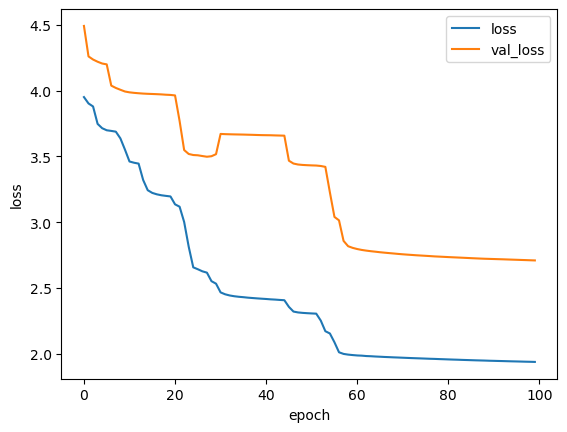

In [68]:
plt.plot(hist.loss, label = "loss")
plt.plot(hist.val_loss, label = "val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()

In [69]:
model_big = tf.keras.Sequential([
        tf.keras.layers.Input(shape = (13)),
        tf.keras.layers.Dense(64, activation = 'relu'),
        tf.keras.layers.Dense(16, activation = 'relu'),
        tf.keras.layers.Dense(1)
])
model_big.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])
EPOCHS = 100

history_big = model_big.fit(X_train, y_train, epochs = EPOCHS, validation_data=(X_val, y_val))


Epoch 1/100
6/6 [==============================] - 0s 22ms/step - loss: 1.6692 - accuracy: 0.5580 - val_loss: 1.1234 - val_accuracy: 0.5902
Epoch 2/100
6/6 [==============================] - 0s 7ms/step - loss: 1.1869 - accuracy: 0.6685 - val_loss: 1.0425 - val_accuracy: 0.6230
Epoch 3/100
6/6 [==============================] - 0s 8ms/step - loss: 0.7759 - accuracy: 0.7348 - val_loss: 0.7904 - val_accuracy: 0.6885
Epoch 4/100
6/6 [==============================] - 0s 10ms/step - loss: 0.5818 - accuracy: 0.7569 - val_loss: 0.7375 - val_accuracy: 0.7213
Epoch 5/100
6/6 [==============================] - 0s 8ms/step - loss: 0.5297 - accuracy: 0.7845 - val_loss: 0.7066 - val_accuracy: 0.7213
Epoch 6/100
6/6 [==============================] - 0s 7ms/step - loss: 0.4901 - accuracy: 0.7901 - val_loss: 0.6872 - val_accuracy: 0.7213
Epoch 7/100
6/6 [==============================] - 0s 9ms/step - loss: 0.4577 - accuracy: 0.8287 - val_loss: 0.6754 - val_accuracy: 0.7377
Epoch 8/100
6/6 [========

6/6 [==============================] - 0s 6ms/step - loss: 0.1744 - accuracy: 0.9669 - val_loss: 1.1783 - val_accuracy: 0.7705
Epoch 60/100
6/6 [==============================] - 0s 6ms/step - loss: 0.1726 - accuracy: 0.9669 - val_loss: 1.3304 - val_accuracy: 0.7705
Epoch 61/100
6/6 [==============================] - 0s 6ms/step - loss: 0.1705 - accuracy: 0.9669 - val_loss: 1.3332 - val_accuracy: 0.7705
Epoch 62/100
6/6 [==============================] - 0s 6ms/step - loss: 0.1691 - accuracy: 0.9669 - val_loss: 1.3365 - val_accuracy: 0.7705
Epoch 63/100
6/6 [==============================] - 0s 6ms/step - loss: 0.1674 - accuracy: 0.9724 - val_loss: 1.3355 - val_accuracy: 0.7705
Epoch 64/100
6/6 [==============================] - 0s 6ms/step - loss: 0.1659 - accuracy: 0.9724 - val_loss: 1.3392 - val_accuracy: 0.7705
Epoch 65/100
6/6 [==============================] - 0s 6ms/step - loss: 0.1643 - accuracy: 0.9669 - val_loss: 1.3403 - val_accuracy: 0.7705
Epoch 66/100
6/6 [===============

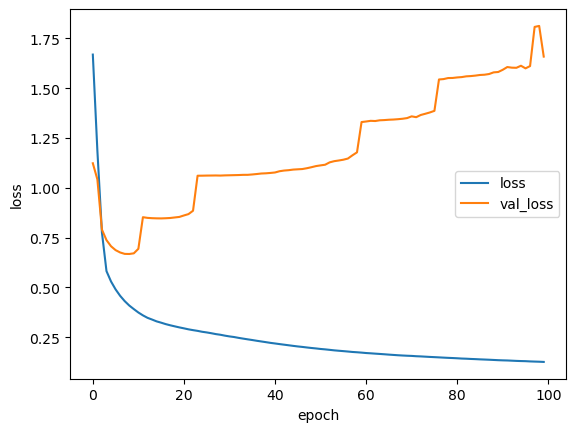

In [70]:
hist_big = pd.DataFrame(history_big.history)

plt.plot(hist_big.loss, label = "loss")
plt.plot(hist_big.val_loss, label = "val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()

In [71]:
model_small = tf.keras.Sequential([
        tf.keras.layers.Input(shape = (13)),
        tf.keras.layers.Dense(8, activation = 'relu'),
        tf.keras.layers.Dense(4, activation = 'relu'),
        tf.keras.layers.Dense(1)
])
model_small.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])
EPOCHS = 100

history_small = model_small.fit(X_train, y_train, epochs = EPOCHS, validation_data=(X_val, y_val))


Epoch 1/100
6/6 [==============================] - 1s 22ms/step - loss: 2.4599 - accuracy: 0.4917 - val_loss: 4.0291 - val_accuracy: 0.3607
Epoch 2/100
6/6 [==============================] - 0s 8ms/step - loss: 2.3311 - accuracy: 0.5193 - val_loss: 3.9658 - val_accuracy: 0.3607
Epoch 3/100
6/6 [==============================] - 0s 6ms/step - loss: 2.2742 - accuracy: 0.5138 - val_loss: 3.9306 - val_accuracy: 0.3770
Epoch 4/100
6/6 [==============================] - 0s 8ms/step - loss: 2.1877 - accuracy: 0.5470 - val_loss: 3.7409 - val_accuracy: 0.4098
Epoch 5/100
6/6 [==============================] - 0s 7ms/step - loss: 2.0226 - accuracy: 0.5691 - val_loss: 3.8610 - val_accuracy: 0.4262
Epoch 6/100
6/6 [==============================] - 0s 7ms/step - loss: 1.7546 - accuracy: 0.6077 - val_loss: 3.6194 - val_accuracy: 0.4262
Epoch 7/100
6/6 [==============================] - 0s 8ms/step - loss: 1.6224 - accuracy: 0.6354 - val_loss: 3.5850 - val_accuracy: 0.4590
Epoch 8/100
6/6 [=========

6/6 [==============================] - 0s 7ms/step - loss: 0.8044 - accuracy: 0.7238 - val_loss: 2.6179 - val_accuracy: 0.5738
Epoch 60/100
6/6 [==============================] - 0s 7ms/step - loss: 0.8020 - accuracy: 0.7238 - val_loss: 2.6162 - val_accuracy: 0.5902
Epoch 61/100
6/6 [==============================] - 0s 6ms/step - loss: 0.7999 - accuracy: 0.7238 - val_loss: 2.6146 - val_accuracy: 0.5902
Epoch 62/100
6/6 [==============================] - 0s 6ms/step - loss: 0.7976 - accuracy: 0.7238 - val_loss: 2.6132 - val_accuracy: 0.5902
Epoch 63/100
6/6 [==============================] - 0s 6ms/step - loss: 0.7953 - accuracy: 0.7238 - val_loss: 2.6116 - val_accuracy: 0.5902
Epoch 64/100
6/6 [==============================] - 0s 6ms/step - loss: 0.7931 - accuracy: 0.7238 - val_loss: 2.6103 - val_accuracy: 0.5902
Epoch 65/100
6/6 [==============================] - 0s 6ms/step - loss: 0.7912 - accuracy: 0.7238 - val_loss: 2.6089 - val_accuracy: 0.6066
Epoch 66/100
6/6 [===============

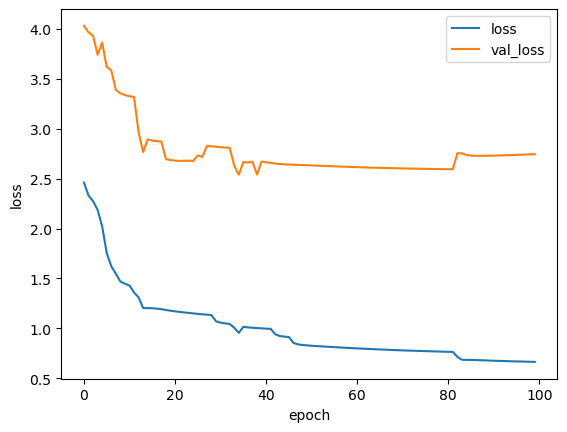

In [72]:
hist_small = pd.DataFrame(history_small.history)

plt.plot(hist_small.loss, label = "loss")
plt.plot(hist_small.val_loss, label = "val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()

In [73]:
model_tiny = tf.keras.Sequential([
        tf.keras.layers.Input(shape = (13)),
        tf.keras.layers.Dense(4, activation = 'relu'),
        tf.keras.layers.Dense(2, activation = 'relu'),
        tf.keras.layers.Dense(1)
])
model_tiny.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])
EPOCHS = 100

history_tiny = model_tiny.fit(X_train, y_train, epochs = EPOCHS, validation_data=(X_val, y_val))


Epoch 1/100
6/6 [==============================] - 0s 21ms/step - loss: 8.6073 - accuracy: 0.4420 - val_loss: 7.5860 - val_accuracy: 0.5082
Epoch 2/100
6/6 [==============================] - 0s 9ms/step - loss: 8.6073 - accuracy: 0.4420 - val_loss: 7.5860 - val_accuracy: 0.5082
Epoch 3/100
6/6 [==============================] - 0s 8ms/step - loss: 8.6073 - accuracy: 0.4420 - val_loss: 7.5860 - val_accuracy: 0.5082
Epoch 4/100
6/6 [==============================] - 0s 7ms/step - loss: 8.6073 - accuracy: 0.4420 - val_loss: 7.5860 - val_accuracy: 0.5082
Epoch 5/100
6/6 [==============================] - 0s 7ms/step - loss: 8.6073 - accuracy: 0.4420 - val_loss: 7.5860 - val_accuracy: 0.5082
Epoch 6/100
6/6 [==============================] - 0s 7ms/step - loss: 8.6073 - accuracy: 0.4420 - val_loss: 7.5860 - val_accuracy: 0.5082
Epoch 7/100
6/6 [==============================] - 0s 8ms/step - loss: 8.6073 - accuracy: 0.4420 - val_loss: 7.5860 - val_accuracy: 0.5082
Epoch 8/100
6/6 [=========

6/6 [==============================] - 0s 7ms/step - loss: 8.6073 - accuracy: 0.4420 - val_loss: 7.5860 - val_accuracy: 0.5082
Epoch 60/100
6/6 [==============================] - 0s 7ms/step - loss: 8.6073 - accuracy: 0.4420 - val_loss: 7.5860 - val_accuracy: 0.5082
Epoch 61/100
6/6 [==============================] - 0s 7ms/step - loss: 8.6073 - accuracy: 0.4420 - val_loss: 7.5860 - val_accuracy: 0.5082
Epoch 62/100
6/6 [==============================] - 0s 6ms/step - loss: 8.6073 - accuracy: 0.4420 - val_loss: 7.5860 - val_accuracy: 0.5082
Epoch 63/100
6/6 [==============================] - 0s 7ms/step - loss: 8.6073 - accuracy: 0.4420 - val_loss: 7.5860 - val_accuracy: 0.5082
Epoch 64/100
6/6 [==============================] - 0s 7ms/step - loss: 8.6073 - accuracy: 0.4420 - val_loss: 7.5860 - val_accuracy: 0.5082
Epoch 65/100
6/6 [==============================] - 0s 7ms/step - loss: 8.6073 - accuracy: 0.4420 - val_loss: 7.5860 - val_accuracy: 0.5082
Epoch 66/100
6/6 [===============

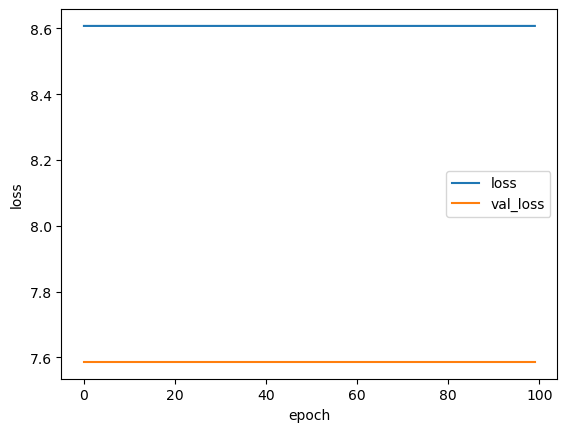

In [74]:
hist_tiny = pd.DataFrame(history_tiny.history)

plt.plot(hist_tiny.loss, label = "loss")
plt.plot(hist_tiny.val_loss, label = "val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()

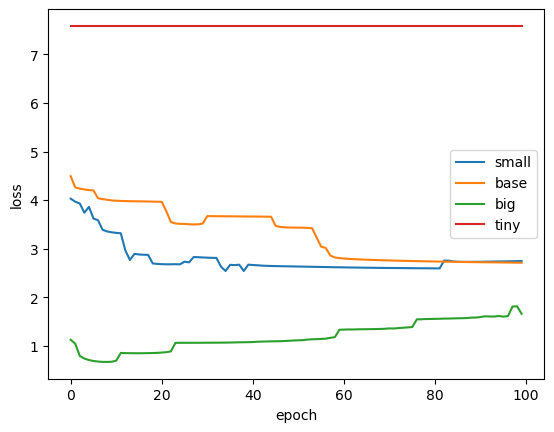

In [75]:
plt.plot(hist_small.val_loss, label = "small")
plt.plot(hist.val_loss, label = "base")
plt.plot(hist_big.val_loss, label = "big")
plt.plot(hist_tiny.val_loss, label = "tiny")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()

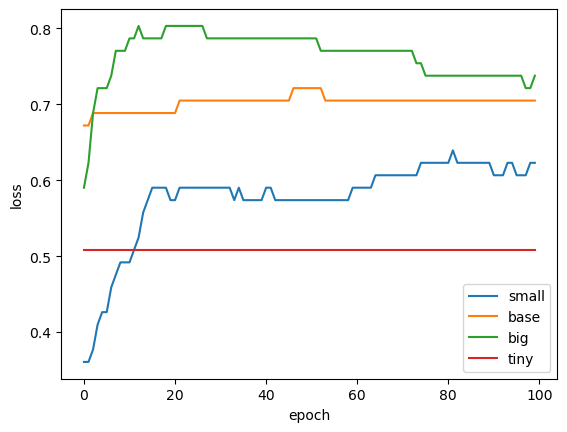

In [76]:
plt.plot(hist_small.val_accuracy, label = "small")
plt.plot(hist.val_accuracy, label = "base")
plt.plot(hist_big.val_accuracy, label = "big")
plt.plot(hist_tiny.val_accuracy, label = "tiny")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()

In [77]:
output_tiny = model_tiny.evaluate(X_test, y_test)
output_small = model_small.evaluate(X_test, y_test)
output_base = model.evaluate(X_test, y_test)
output_big = model_big.evaluate(X_test, y_test)

2/2 [==============================] - 0s 3ms/step - loss: 1.8483 - accuracy: 0.7213
